# 2.6 Probability and Statistics

Machine learning is, in one way or another, about reasoning under uncertainty. A
supervised model rarely just wants a point prediction — it often needs to say
*how confident* it is, and an unsupervised model needs some notion of how
likely a given observation is under the population it was trained on.
**Probability** is the mathematical language for this.

Two schools give probability different meanings. **Frequentists** treat
$P(A)$ as the long-run frequency of a repeatable event, like the fraction of
coin tosses that land heads. **Bayesians** use the same machinery more
broadly, as a *degree of belief* that can apply even to one-off,
non-repeatable events (will this dam collapse?), and that gets updated as new
evidence arrives — the update rule is **Bayes' theorem**, the centerpiece of
this notebook.

We will (1) estimate a probability empirically by simulating coin tosses, (2)
put probability on a formal footing with Kolmogorov's axioms, (3) work
through joint, conditional, and marginal probabilities for multiple random
variables, (4) derive and apply Bayes' theorem on a classic HIV-testing
example, and (5) define expectation and variance, the two numbers used most
often to summarize a distribution.

In [1]:
%matplotlib inline
import random
import torch
from torch.distributions.multinomial import Multinomial
import matplotlib.pyplot as plt

## 2.6.1 A Simple Example: Tossing Coins

Suppose we want to know how likely a coin is to land heads. If the coin is
fair, symmetry says heads and tails are equally likely, so we expect the
*fraction* of heads over many tosses to sit at $\tfrac12$. That value,
$P(\text{heads}) = 0.5$, is a **probability**: a theoretical property of the
coin itself, always between 0 and 1, with 1 meaning certainty and 0 meaning
impossibility.

The fraction of heads we actually *observe* in $n$ tosses, $n_h / n$, is not
a probability — it is a **statistic**: an empirical quantity computed from
data, which we use to *estimate* the underlying probability. The simplest
such estimator is exactly this ratio of observed heads to total tosses.
Below we build that estimator two ways: first with plain Python randomness,
then with PyTorch's `Multinomial` distribution.

In [2]:
# Set the total number of coin flips to simulate
num_tosses = 100

# Simulate the tosses using a list comprehension:
# 1. random.random() generates a number between 0.0 and 1.0.
# 2. We define 'Heads' as any number greater than 0.5 (a 50% probability).
# 3. The comparison (> 0.5) returns True for Heads and False for Tails.
# 4. sum() treats True as 1 and False as 0, effectively counting the Heads.
heads = sum([random.random() > 0.5 for _ in range(num_tosses)])

# Calculate tails by subtracting the heads count from the total
tails = num_tosses - heads

print("heads, tails: ", [heads, tails])

heads, tails:  [47, 53]


More generally, any experiment with a finite set of outcomes — a coin toss, a
die roll — can be simulated in one call with
`torch.distributions.multinomial.Multinomial`: give it the number of draws
and a probability vector (one entry per outcome, summing to 1), and it
returns a tensor of counts, one per outcome. Here `fair_probs = [0.5, 0.5]`
puts index 0 on heads and index 1 on tails.

In [3]:
# 1. Define the probabilities for each outcome.
# Since we have two values (0.5, 0.5), this simulates a fair coin (Heads/Tails).
# If you had a 6-sided die, this tensor would have 6 values summing to 1.0.
fair_probs = torch.tensor([0.5, 0.5])

# 2. Create the distribution and sample from it.
# '100' is the number of trials (coin tosses).
# 'fair_probs' assigns the probability weight to each outcome.
# .sample() runs the experiment once and counts the results.
#
# The output will be a tensor of counts, e.g., tensor([48., 52.])
# meaning 48 Heads and 52 Tails (summing to 100).
Multinomial(100, fair_probs).sample()

tensor([47., 53.])

Even though we set the true probabilities to an exactly fair $[0.5, 0.5]$, a
single run of 100 tosses is unlikely to split exactly 50/50 — that is
ordinary sampling noise from a small sample size, not evidence the coin is
biased. Dividing the counts by the number of draws turns them into
**frequencies**, which (like the probabilities they estimate) always sum to
1. The next cell compares the frequencies from 100 draws against 10,000
draws — bigger samples should land closer to the true $0.5$.

In [4]:
(Multinomial(100, fair_probs).sample() / 100,      # frequencies from only 100 draws -- still noisy
 Multinomial(10000, fair_probs).sample() / 10000)  # frequencies from 10000 draws -- much closer to the true 0.5, 0.5

(tensor([0.4200, 0.5800]), tensor([0.4876, 0.5124]))

This is the **law of large numbers** at work: as the number of repetitions
$n$ grows, an estimator like this one converges to the true probability it
targets. The central limit theorem further says the typical error should
shrink at a rate of roughly $1/\sqrt{n}$. To see the convergence directly, we
simulate 400 *individual* coin tosses (`Multinomial(1, ...)`, one toss at a
time) and track the running estimate $n_h/n$ after every toss — the same
estimator as above, just re-computed at every step instead of only once.

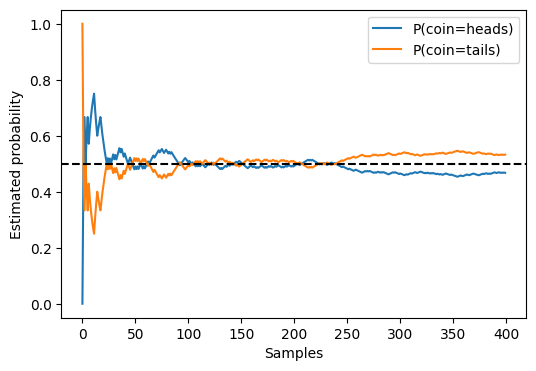

In [5]:
counts = Multinomial(1, fair_probs).sample((400,))         # 400 single-toss experiments, one-hot counts each
cum_counts = counts.cumsum(dim=0)                           # running total of heads/tails after each toss
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)  # running frequency: n_heads/n so far, n_tails/n so far
estimates = estimates.numpy()
plt.figure(figsize=(6, 4))
plt.plot(estimates[:, 0], label=("P(coin=heads)"))          # estimated P(heads) after each toss
plt.plot(estimates[:, 1], label=("P(coin=tails)"))          # estimated P(tails) after each toss
plt.axhline(y=0.5, color='black', linestyle='dashed')        # true probability, for reference
plt.gca().set_xlabel('Samples')
plt.gca().set_ylabel('Estimated probability')
plt.legend();

Each curve should visibly wobble at first and then settle down near the
dashed $0.5$ line as more tosses accumulate — the two solid curves mirror
each other since heads and tails frequencies always sum to 1. `Multinomial`
is only one of many distributions PyTorch ships with; here's a quick look at
what else is available for later sections.

In [6]:
print(dir(torch.distributions))

['AbsTransform', 'AffineTransform', 'Bernoulli', 'Beta', 'Binomial', 'CatTransform', 'Categorical', 'Cauchy', 'Chi2', 'ComposeTransform', 'ContinuousBernoulli', 'CorrCholeskyTransform', 'CumulativeDistributionTransform', 'Dirichlet', 'Distribution', 'ExpTransform', 'Exponential', 'ExponentialFamily', 'FisherSnedecor', 'Gamma', 'GeneralizedPareto', 'Geometric', 'Gumbel', 'HalfCauchy', 'HalfNormal', 'Independent', 'IndependentTransform', 'InverseGamma', 'Kumaraswamy', 'LKJCholesky', 'Laplace', 'LogNormal', 'LogisticNormal', 'LowRankMultivariateNormal', 'LowerCholeskyTransform', 'MixtureSameFamily', 'Multinomial', 'MultivariateNormal', 'NegativeBinomial', 'Normal', 'OneHotCategorical', 'OneHotCategoricalStraightThrough', 'Pareto', 'Poisson', 'PositiveDefiniteTransform', 'PowerTransform', 'RelaxedBernoulli', 'RelaxedOneHotCategorical', 'ReshapeTransform', 'SigmoidTransform', 'SoftmaxTransform', 'SoftplusTransform', 'StackTransform', 'StickBreakingTransform', 'StudentT', 'TanhTransform', 'T

## 2.6.2 A More Formal Treatment

To go further we need more precision. The **sample space** $S$ is the set of
all possible outcomes of a random experiment — $S = \{\text{heads},
\text{tails}\}$ for one coin, $S = \{1,2,3,4,5,6\}$ for one die. An **event**
is any subset of $S$; for a die, "seeing an odd number" is the event
$B = \{1, 3, 5\}$.

A probability function $P: A \subseteq S \to [0, 1]$ must satisfy three
axioms (Kolmogorov, 1933):

- $P(A) \ge 0$ for every event $A$;
- $P(S) = 1$ — some outcome always happens;
- for mutually exclusive events $A_1, A_2, \dots$ (i.e. $A_i \cap A_j =
  \varnothing$ for $i \neq j$), $\displaystyle P\Big(\bigcup_{i} A_i\Big) =
  \sum_i P(A_i)$.

These three rules are all that is needed to derive the rest of probability
theory — for instance, that $P(A) + P(A^c) = 1$ for any event and its
complement, and that the impossible event has $P(\varnothing) = 0$.

## 2.6.3 Random Variables

A **random variable** is a mapping from the sample space to a set of values
— "the coin toss comes up heads" and "the die roll is odd" are both random
variables in this sense. Random variables can be coarser than the raw sample
space (a variable can just ask "greater than 0.5?" even over an infinite
space of outcomes), and several random variables can share the same
underlying sample space, which is exactly what lets one variable carry
information about another — e.g. knowing a home alarm went off makes a
burglary more plausible.

We write $P(X = v)$ for the probability that random variable $X$ takes value
$v$, and often abuse notation further: $P(X)$ for the whole distribution of
$X$, or just $P(v)$ when $X$ is clear from context.

**Discrete** random variables (a coin flip, a die roll) take values from a
countable set, so $P(X=v)$ is a meaningful number for every $v$.
**Continuous** random variables (a person's height) instead have a
**probability density**: any single exact value has zero probability, and we
integrate the density over an interval to get the probability of landing in
that interval.

## 2.6.4 Multiple Random Variables

Most of machine learning is about relationships *between* random variables —
how the features relate to the label, say. The **joint probability**
$P(A=a, B=b)$ is the probability that $A$ takes value $a$ *and* $B$ takes
value $b$ simultaneously; since both have to happen, $P(A{=}a, B{=}b) \le
P(A{=}a)$ and $P(A{=}a, B{=}b) \le P(B{=}b)$.

The joint distribution determines everything else about $A$ and $B$. In
particular we can recover an individual ("**marginal**") distribution by
summing the joint over every value of the other variable:

$$P(A=a) = \sum_{v} P(A=a, B=v).$$

Dividing the joint by one of the marginals gives the **conditional
probability** — how likely $B=b$ becomes once we know $A=a$ occurred:

$$P(B=b \mid A=a) = \frac{P(A=a, B=b)}{P(A=a)}.$$

Conditioning just restricts attention to the slice of the sample space where
$A=a$ and renormalizes it to sum to 1 again — so conditional probabilities
are ordinary probabilities and obey the same three axioms.

Combining $P(A,B) = P(B \mid A)P(A)$ with $P(A,B) = P(A \mid B)P(B)$ and
equating the two gives **Bayes' theorem**:

$$P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)}.$$

This is what lets us *reverse* a conditioning direction: if $P(B \mid A)$ is
easy to estimate but $P(A \mid B)$ is what we actually want, Bayes' theorem
gets us there. In the Bayesian framing, $P(A)$ is the **prior** belief,
$P(B \mid A)$ is the **likelihood** of the evidence under that belief, and
$P(A \mid B)$ is the resulting **posterior**. When $P(B)$ itself is hard to
pin down, we can fall back on the unnormalized form $P(A \mid B) \propto
P(B \mid A) P(A)$ and recover the normalizer from marginalization, since
$\sum_a P(A{=}a \mid B) = 1$:

$$P(A \mid B) = \frac{P(B \mid A)\,P(A)}{\sum_{a} P(B \mid A=a)\,P(A=a)}.$$

That denominator is marginalization again — summing $P(B \mid A=a)P(A=a) =
P(B, A=a)$ over every $a$ recovers $P(B)$.

Two variables are **independent**, written $A \perp B$, when conditioning on
one tells you nothing about the other: $P(A \mid B) = P(A)$, equivalently
$P(A, B) = P(A)P(B)$. Two coin tosses from different coins are independent
in this sense — knowing one came up heads says nothing about the other.

The same idea extends to **conditional independence**: $A$ and $B$ are
conditionally independent given $C$ when $P(A, B \mid C) = P(A \mid C)\,
P(B \mid C)$. Independence is not fixed once and for all — variables that
are dependent unconditionally can become independent once you condition on
a common cause (shoe size and reading level correlate across all
elementary-school students, but the correlation disappears once you
condition on age), and variables that are independent unconditionally can
become dependent once you condition on a common effect. We lean on
conditional independence directly in the worked example below, when
combining two diagnostic tests.

## 2.6.5 An Example

A doctor administers an HIV test. Let $H \in \{0,1\}$ be the true HIV status
and $D_1 \in \{0,1\}$ the first test's result. The test never misses an
actual infection but has a 1% false-positive rate on healthy patients:

| | $H=1$ | $H=0$ |
|---|---|---|
| $P(D_1=1 \mid H)$ | $1$ | $0.01$ |
| $P(D_1=0 \mid H)$ | $0$ | $0.99$ |

Given a positive result, what is $P(H=1 \mid D_1=1)$? Intuitively this
should depend heavily on how rare the disease is — take the population
prevalence to be $P(H=1) = 0.0015$. We first marginalize to get
$P(D_1=1)$, then apply Bayes' theorem.

In [7]:
# H = 1 means infected; D1 = 1 means the first test is positive.
p_H1 = 0.0015                                  # prior prevalence P(H=1)
p_D1_given_H1 = 1.0                            # sensitivity: P(D1=1 | H=1)
p_D1_given_H0 = 0.01                           # false-positive rate: P(D1=1 | H=0)

# Marginalize over H: P(D1=1) = P(D1=1|H=1) P(H=1) + P(D1=1|H=0) P(H=0)
p_D1 = p_D1_given_H1 * p_H1 + p_D1_given_H0 * (1 - p_H1)

# Bayes' theorem: P(H=1 | D1=1) = P(D1=1 | H=1) P(H=1) / P(D1=1)
p_H1_given_D1 = p_D1_given_H1 * p_H1 / p_D1

print(f'P(D1=1)        = {p_D1:.6f}')          # book: 0.011485
print(f'P(H=1 | D1=1)  = {p_H1_given_D1:.4f}')  # book: 0.1306

P(D1=1)        = 0.011485
P(H=1 | D1=1)  = 0.1306


Despite a seemingly accurate test, a single positive only pushes belief in
infection up to about **13%** — false positives from the overwhelmingly
healthy majority swamp the true positives from the rare infected minority. A
worried patient would reasonably ask for a second, independent test. The
second test is less accurate on its own:

| | $H=1$ | $H=0$ |
|---|---|---|
| $P(D_2=1 \mid H)$ | $0.98$ | $0.03$ |
| $P(D_2=0 \mid H)$ | $0.02$ | $0.97$ |

Assume the two results are **conditionally independent given $H$**, so their
joint likelihood factors: $P(D_1{=}1, D_2{=}1 \mid H) = P(D_1{=}1 \mid H)\,
P(D_2{=}1 \mid H)$. The same Bayes'-theorem machinery, applied to both
results at once, tells us how much a second positive should move our belief.

In [8]:
p_D2_given_H1 = 0.98                           # sensitivity of the second test
p_D2_given_H0 = 0.03                           # false-positive rate of the second test

# Conditional independence given H: the joint likelihood factors into a product.
p_D1D2_given_H1 = p_D1_given_H1 * p_D2_given_H1   # P(D1=1, D2=1 | H=1)
p_D1D2_given_H0 = p_D1_given_H0 * p_D2_given_H0   # P(D1=1, D2=1 | H=0)

# Marginalize again to get P(D1=1, D2=1)
p_D1D2 = p_D1D2_given_H1 * p_H1 + p_D1D2_given_H0 * (1 - p_H1)

# Bayes' theorem with both tests taken as joint evidence
p_H1_given_D1D2 = p_D1D2_given_H1 * p_H1 / p_D1D2

print(f'P(D1=1, D2=1)         = {p_D1D2:.8f}')          # book: 0.00176955
print(f'P(H=1 | D1=1, D2=1)   = {p_H1_given_D1D2:.4f}')  # book: 0.8307

P(D1=1, D2=1)         = 0.00176955
P(H=1 | D1=1, D2=1)   = 0.8307


Two positives push the posterior all the way up to about **83%** — even
though the second test is individually weaker, it still adds real
information because its errors are (assumed) independent of the first
test's errors. If we instead ran the *same* test twice, we would expect the
same outcome both times and would learn essentially nothing new. This is
Bayes' theorem doing exactly what a classifier does: turning more features
(test results) into a more confident decision.

## 2.6.6 Expectations

Beyond individual event probabilities, it is often useful to summarize a
whole distribution with a couple of numbers. The **expectation** (or mean)
of a random variable $X$ is the probability-weighted average of its possible
values:

$$E[X] = E_{x \sim P}[x] = \sum_x x\, P(X=x),$$

and more generally, for any function $f$ of $x$:

$$E_{x \sim P}[f(x)] = \sum_x f(x)\, P(x).$$

The **variance** measures how spread out $X$ is around its mean — the
expected squared deviation:

$$\mathrm{Var}[X] = E\big[(X - E[X])^2\big] = E[X^2] - E[X]^2,$$

and its square root, the **standard deviation**, carries the same units as
$X$ itself. As a concrete case, take an investment that fails outright with
50% probability, returns \$2 with 40% probability, and returns \$10 with 10%
probability.

In [9]:
returns = torch.tensor([0.0, 2.0, 10.0])   # possible payoffs
probs   = torch.tensor([0.5, 0.4, 0.1])    # P(X = each payoff)

expectation = (returns * probs).sum()                       # E[X] = sum_x x P(x)
variance    = (returns ** 2 * probs).sum() - expectation ** 2  # Var[X] = E[X^2] - E[X]^2

print(f'E[X]   = {expectation:.2f}')    # book: 1.8
print(f'Var[X] = {variance:.2f}')       # book: 8.36

E[X]   = 1.80
Var[X] = 8.36


These match the book's own numbers: an expected return of \$1.80 with a
variance of 8.36 — high variance relative to the mean marks this as a risky
bet. The same definitions extend to vector-valued random variables: the mean
$\boldsymbol{\mu} = E_{\mathbf{x}\sim P}[\mathbf{x}]$ is applied elementwise,
while the spread becomes a **covariance matrix**
$\boldsymbol{\Sigma} = E_{\mathbf{x}\sim P}\big[(\mathbf{x}-\boldsymbol{\mu})
(\mathbf{x}-\boldsymbol{\mu})^\top\big]$, whose off-diagonal entries capture
how correlated different coordinates are.

## 2.6.7 Discussion

Machine learning carries at least two distinct flavors of uncertainty.
**Aleatoric uncertainty** is intrinsic randomness that no amount of data
removes — even knowing a coin's true $P(\text{heads})$ exactly, any single
future toss is still a coin flip. **Epistemic uncertainty** is uncertainty
about a model's parameters (e.g. not yet knowing that true
$P(\text{heads})$), and it *is* reducible by collecting more data.

That reduction is typically slow: estimators like the one in §2.6.1 converge
at a rate of roughly $1/\sqrt{n}$, so going from 10 to 1,000 tosses buys a
tenfold drop in uncertainty, while the next 1,000 tosses buy only another
$\sqrt{10} \approx 1.41\times$ — a pattern of fast early gains and steep
diminishing returns that recurs throughout machine learning.

Bayes' theorem is the tool for combining a **prior** with a **likelihood**
to reach a **posterior**, and expectation and variance are not the only lens
on a distribution but a genuinely useful one: **Chebyshev's inequality**,
$P(|X - \mu| \ge k\sigma) \le 1/k^2$, uses only the mean and variance to
guarantee that at least 50% of a distribution's mass sits within roughly
$1.41\sigma$ of its mean — no matter the shape of the distribution.

## Summary

- **Probability** is a theoretical property of the data-generating process;
  a **statistic** (like an observed frequency) is an empirical estimate of
  it computed from data. `Multinomial` lets us simulate the latter to study
  how well it recovers the former.
- Three **axioms** (Kolmogorov) — nonnegativity, $P(S)=1$, and additivity
  over mutually exclusive events — are all probability theory needs as a
  foundation.
- A **random variable** maps outcomes to values; it can be **discrete**
  (exact probabilities) or **continuous** (probability densities, integrated
  over an interval).
- **Joint** probability $P(A,B)$ determines everything else: sum over one
  variable to get a **marginal**, divide by a marginal to get a
  **conditional** $P(B\mid A) = P(A,B)/P(A)$.
- **Bayes' theorem**, $P(A\mid B) = P(B\mid A)P(A)/P(B)$, reverses the
  direction of conditioning — turning an easy-to-estimate likelihood and a
  prior into the posterior we actually want, as in the HIV example: one
  positive test only reaches a 13% posterior, but two conditionally
  independent positive tests reach 83%.
- **Independence** ($P(A,B)=P(A)P(B)$) and **conditional independence**
  given a third variable are assumptions, not guarantees — check before you
  rely on them, since conditioning can create or destroy dependence.
- **Expectation** $E[X]=\sum_x xP(x)$ and **variance**
  $\mathrm{Var}[X]=E[X^2]-E[X]^2$ summarize a distribution's center and
  spread; both extend elementwise / via a covariance matrix to
  vector-valued random variables.
- Estimators typically converge at a $1/\sqrt{n}$ rate, so uncertainty
  shrinks fast at first and then slowly — collecting 100x more data only
  buys a 10x reduction in uncertainty.